# **Customer Segmentation**
Unsipervised learning project dividing customers into groups based on based on various attributes of their card info and usage.  
First step, we load and inspect the dataset.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os

print(os.listdir())
warnings.filterwarnings('ignore')
cards = pd.read_csv("Customer Data.csv")

['.git', '.gitignore', '.ipynb_checkpoints', 'Customer Data.csv', 'customer segmentation.ipynb', 'Customer_Data (1).xlsx', 'README.md', 'Untitled.ipynb']


In [2]:
cards

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [3]:
cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
cards.duplicated().sum()

np.int64(0)

In [5]:
cards.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Dataset has 8.950 observations and 18 labels. 314 missing values across 2 variables, with all but one of them coming from Minimum Payments. No duplicate entries, and all variables are in numerical data types.

### **Step 2**
Now, after inspection, we proceed to clean and preprocess our dataset. There is only one collection error identified, so this should be fairly straightforward.

In [6]:
cards.drop(columns='CUST_ID', inplace=True) # drop customer ID column

Missing data is concentrated in one variable, which leads me to beleive it is not missing completely at random. We'll ascertain what kind of missing data it is by mean computation.

In [7]:
cards['Missing'] = cards['MINIMUM_PAYMENTS'].isnull()
cards

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Missing
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,False
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,False
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,False
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,True
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,False
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6,True
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,False
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,False


In [8]:
non_missing = cards[cards['Missing'] == False]
missing = cards[cards['Missing'] == True]

non_missing_mean = non_missing['BALANCE'].mean()
missing_mean = missing['BALANCE'].mean()

diff = non_missing_mean - missing_mean

In [9]:
print(np.ptp(cards['BALANCE']))
diff

19043.13856


np.float64(1045.600310709348)

The difference between the means of the Balance values of the two groups is only around 1k. Given the range of the values displayed just above the difference, that would indicate this missingness is not telling of any valuable transactional or financial behaviour. But for surety, let's perform the same mean computation for payments made.

In [10]:
non_missing_pmean = non_missing['PAYMENTS'].mean()
missing_pmean = missing['PAYMENTS'].mean()

diff2 = non_missing_pmean - missing_pmean

In [11]:
print(np.ptp(cards['PAYMENTS']))
diff2

50721.48336


np.float64(1461.9863689166773)

The difference between the means of the mayments made by those with missing minimum payments values and those without is only 1461, only around 7% of the range of payments values.I think we can safely assume that the missing values are MCAR, and handle them accordingly. There are only 316 such entries out of 9k, so we can drop them and still retain a decent representation of the collection's tru tendencies.

In [12]:
cards.dropna(subset='MINIMUM_PAYMENTS', inplace=True)

In [13]:
cards['CREDIT_LIMIT'].fillna(value=cards['CREDIT_LIMIT'].mean(), inplace=True)
cards.drop(columns='Missing', inplace=True)
cards.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

All missing values have been handled.

### Step 3
Here, we perform EDA by visualisation to understand our distributions and key relationships. Tho goal here is to understand where there is most covariation besides the obvious suspects, and to ascertain the kinds of distributions that the most important monetary features are. We start, however, with descriptive statistics

In [14]:
cards.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.000000,8637.00000
mean,1601.041632,0.894951,1025.315149,604.831402,420.794807,994.082050,0.495943,0.205885,0.368778,0.137608,3.313651,15.031492,4522.091030,1784.272537,864.206542,0.159285,11.53375
std,2095.519182,0.207833,2167.010602,1684.222861,917.203254,2121.353259,0.401285,0.300044,0.398090,0.201780,6.912151,25.179530,3659.028513,2909.704331,2372.446607,0.296259,1.31226
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163,0.000000,6.00000
25%,147.838347,0.909091,43.300000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,418.446951,169.123707,0.000000,12.00000
50%,916.749476,1.000000,375.240000,44.990000,94.710000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,896.300688,312.343947,0.000000,12.00000
75%,2104.961701,1.000000,1145.850000,598.950000,484.040000,1131.986387,0.916667,0.333333,0.750000,0.250000,4.000000,18.000000,6500.000000,1951.116757,825.485459,0.166667,12.00000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.00000


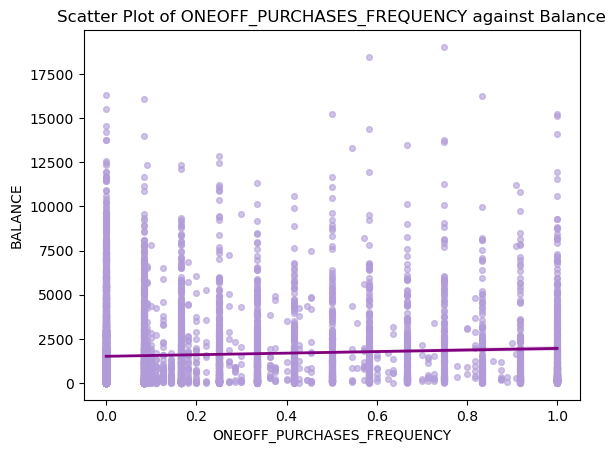

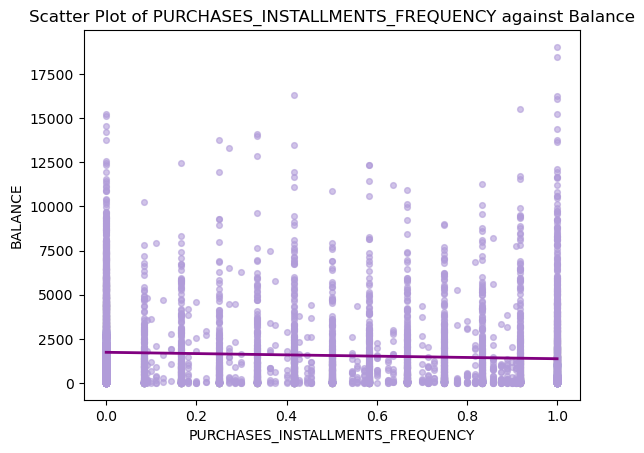

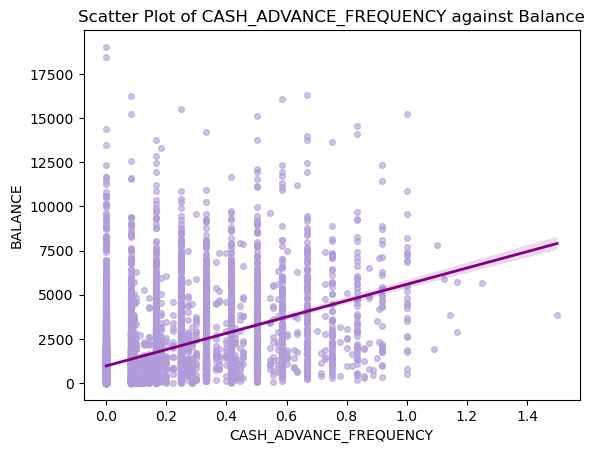

In [24]:
cols = ['ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

for col in cols:
    sns.regplot(x=col, y='BALANCE', data=cards, line_kws={'color': 'purple', 'lw': 2}, color='#B19CD9', scatter_kws={'alpha': 0.6, 's': 17})
    plt.title(f"Scatter Plot of {col} against Balance")
    plt.show()

The graphs displayed above compare three different transactional behaviours to balance. Here's what we can infer;
- Graph 1 shows us the gently upward inclined line of best fit between one-off purchase frequency and outstanding credit card balance, hinting at a slight positive correlation between the two
- Graph 2 shows us that suprisingly, the only ostensible correlation between installment purchase frequency and outstanding credit balance is negative, be it slightly. One may have otherwise presumed to think to the contrary
- Graph 3 shows us a glaring positive correlation between cash advance frequency and credit balance, hinting that frequent cash withdrawal ad usage as opposed to direct credit card purchases may be a debt-incuring and accumulating behaviour.

In [16]:
cards['TOTAL_TRX'] = cards['CASH_ADVANCE_TRX'] + cards['PURCHASES_TRX']
cards['NETSPEND'] = cards['CASH_ADVANCE'] + cards['PURCHASES']

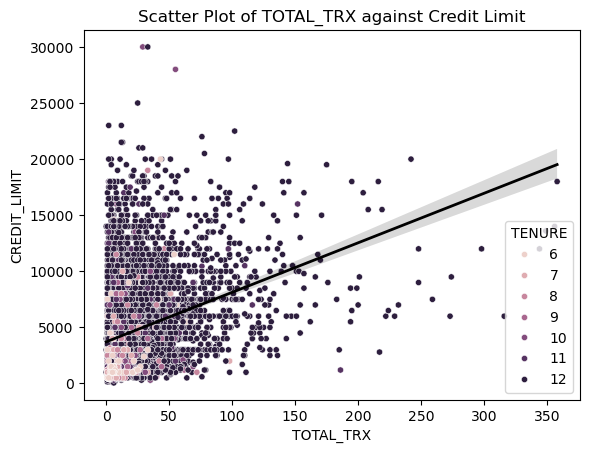

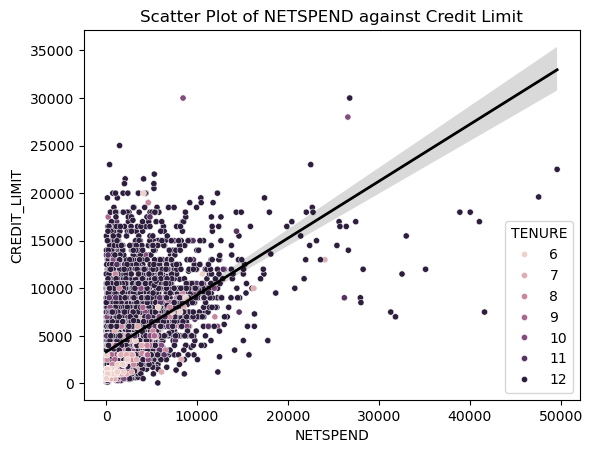

In [23]:
cols = ['TOTAL_TRX', 'NETSPEND']

for col in cols:
    sns.scatterplot(x=col, y='CREDIT_LIMIT', data=cards, s=20, hue='TENURE')
    sns.regplot(x=col, y='CREDIT_LIMIT', data=cards, line_kws={'color': 'black', 'lw': 2}, scatter=False)
    plt.title(f"Scatter Plot of {col} against Credit Limit")
    plt.show()

We can infer with some certainty from the regression plots above that a customer's credit limit increases with card usage, more steeply so with total amount spent than with number of transactions. That is, fewer transactions of greater amounts increase credit limit faster than more transactions of fewer amounts. Of course, both amount spent and transaction number increasing with card usage tenure.

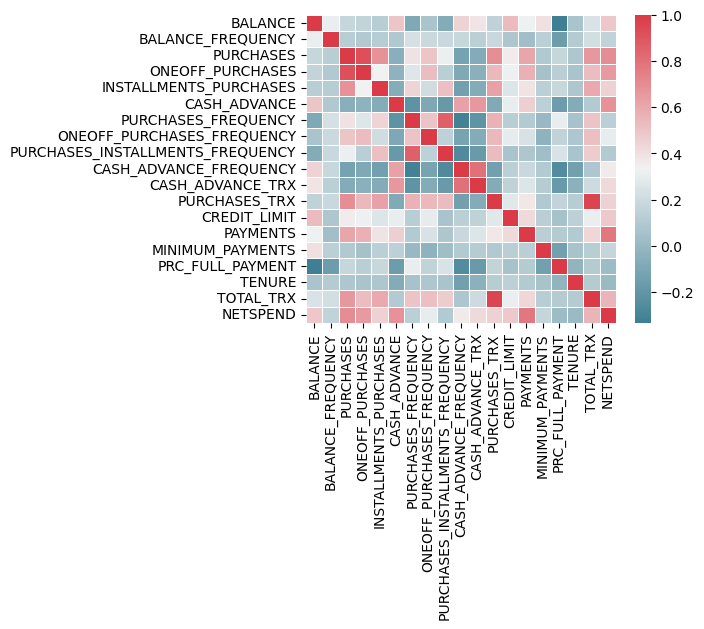

In [25]:
plt.figure(figsize=(5,4))
sns.heatmap(data=cards.corr(), cmap=sns.diverging_palette(220, 10, as_cmap=True), linewidths=.5)
plt.show()

In [ ]:
# note useful inferences from the heatmap

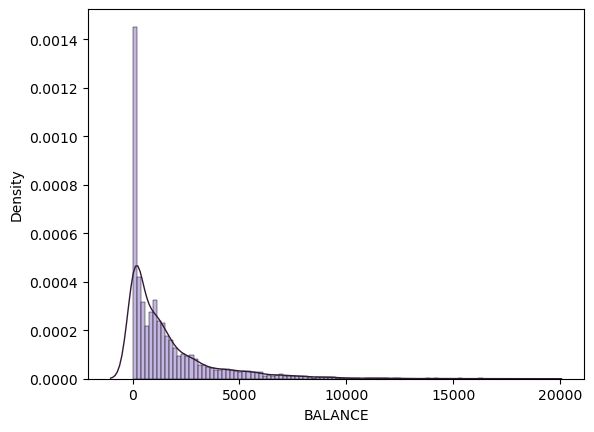

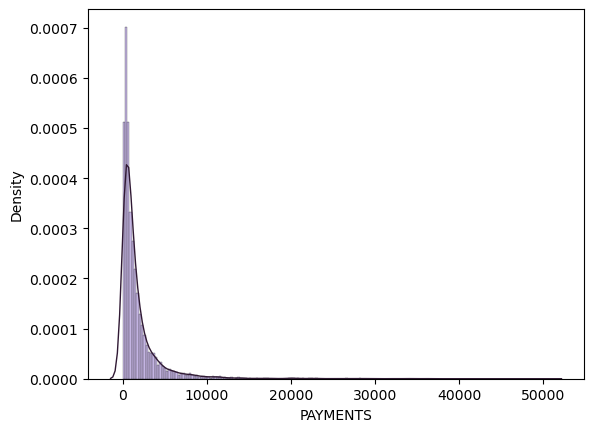

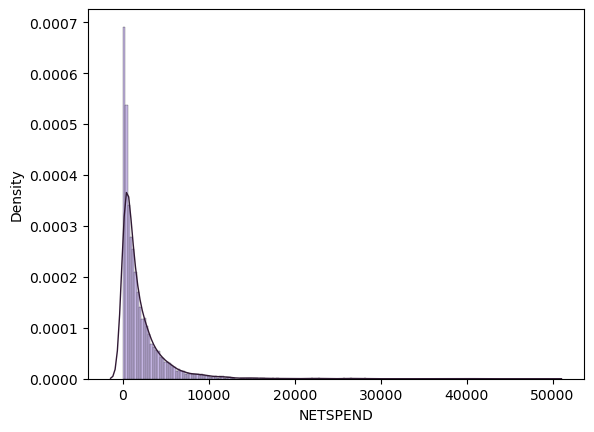

In [26]:
cols = ['BALANCE', 'PAYMENTS', 'NETSPEND']

for col in cols:
    sns.histplot(x=col, data=cards, stat="density", color="#B19CD9", edgecolor="black")
    sns.kdeplot(x=col, data=cards, color="#301934", linewidth=1)
    plt.show()

In [27]:
# note inference from the plots

### Step 4
Now, we carry out all remaining preprocessing to prepare the data for modelling.

In [ ]:
# log transform before scaling below

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [13]:
cols = cards.columns.tolist()

cards[cols] = sc.fit_transform(cards[cols]) # scale each column in the list

In [14]:
cards

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-0.310968,-0.525551,0.360680
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,0.089310,0.234227,0.360680
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-0.101663,-0.525551,0.360680
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,0.000000,-0.525551,0.360680
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-0.265791,-0.525551,0.360680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.737950,0.518084,-0.333293,-0.356934,-0.132643,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960433,-0.486217,-0.349854,1.183951,-4.122768
8946,-0.742423,0.518084,-0.329136,-0.356934,-0.122823,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960433,-0.503396,0.000000,-0.525551,-4.122768
8947,-0.740398,-0.185477,-0.401965,-0.356934,-0.294893,-0.466786,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,-0.960433,-0.570615,-0.335465,0.329200,-4.122768
8948,-0.745174,-0.185477,-0.469552,-0.356934,-0.454576,-0.449352,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,-1.097856,-0.580536,-0.346906,0.329200,-4.122768
